In [1]:
import pandas as pd
import numpy as np
import os 
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sn

In [81]:
list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/').glob("*"))

[PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/.ipynb_checkpoints'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_pos_slope_bs_64_lr_1e-4')]

In [107]:
# Get csvs of results for each model 

def get_df_from_dir(model_paths, talker=False):
    csv_str = 'metrics.csv'
    #models = [attn_models[0], ctrl_models[0]]
    bad_files = []
    dfs = []
    for model in models:
        # get test csvs
        results_csvs = model.rglob("*.csv")

        for csv in results_csvs:
    #         print(csv)
            try:
                df = pd.read_csv(csv)
                #print(model)

                df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
                test_parts = str(model).split("/")[-1].split("_")
                #print(test_parts)
                if talker:
                    df['model'] = test_parts[2]
                    df['snr_condition'] = test_parts[3]
                    df['n_talkers'] = test_parts[0]
                else:
                    df['model'] = test_parts[0]
            #       print(test_parts)
                    df['snr_condition'] = test_parts[1]

        #         if (test_parts[0] == "AttnTrackingControl"):
        #             df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
        #             df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]

                dfs.append(df)
            except Exception as e:
                bad_files.append((csv.as_posix(), e))

    #         if 'Test' in path.as_posix()
    results = pd.concat(dfs, axis=0, ignore_index=True)

    # results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
    # results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
    # results.drop('epoch', axis=1, inplace=True)
    if talker:
        version_maxes = results.groupby(['model', 'snr_condition', 'n_talkers']).version.transform(max)
    else:
        version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
    results = results[results.version == version_maxes]
    return results, bad_files 

In [90]:
bg_models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise').glob("*"))
snr_models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges').glob("*"))
talker_models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr').glob("*"))





In [113]:
# Get csvs of results for each model 

csv_str = 'metrics.csv'
#models = [attn_models[0], ctrl_models[0]]

dfs = []
for model in snr_models:
    # get test csvs
    results_csvs = model.rglob("*.csv")
    for csv in results_csvs:
#         print(csv)
        try:
            df = pd.read_csv(csv)
            #print(model)

            df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
            test_parts = str(model).split("/")[-1].split("_")
            #print(test_parts)
            df['model'] = test_parts[0]
    #       print(test_parts)
            df['snr_condition'] = test_parts[1]

            if (test_parts[0] == "AttnTrackingControl"):
                df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
                df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]

            dfs.append(df)
        except:
            continue
#         if 'Test' in path.as_posix()
results = pd.concat(dfs, axis=0, ignore_index=True)
results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
results.drop('epoch', axis=1, inplace=True)
version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
results = results[results.version == version_maxes]
snr_results = results

In [108]:
bg_results, _ = get_df_from_dir(bg_models)
# snr_results, _ = get_df_from_dir(snr_models)
# talker_results, _ = get_df_from_dir(talker_models, talker=True)


   ACC/test_fg_acc  step version               model snr_condition  \
0              0.0     0       3  AttnCNNConstrained         -10dB   
1              0.0     1       3  AttnCNNConstrained         -10dB   
2              1.0     2       3  AttnCNNConstrained         -10dB   
3              0.0     3       3  AttnCNNConstrained         -10dB   
4              1.0     4       3  AttnCNNConstrained         -10dB   

   ACC/test_fg_acc_step  ACC/test_bg_acc_step  
0                   NaN                   NaN  
1                   NaN                   NaN  
2                   NaN                   NaN  
3                   NaN                   NaN  
4                   NaN                   NaN  
   ACC/test_fg_acc  step version               model snr_condition  \
0              0.0     0       3  AttnCNNConstrained         -10dB   
1              0.0     1       3  AttnCNNConstrained         -10dB   
2              1.0     2       3  AttnCNNConstrained         -10dB   
3          

In [106]:
snr_results.head()

,ACC/test_fg_acc,step,version,model,snr_condition,ACC/test_fg_acc_step,ACC/test_bg_acc_step
0,0.0,0,3,cued model,-10dB,NaN,NaN
1,0.0,1,3,cued model,-10dB,NaN,NaN
2,1.0,2,3,cued model,-10dB,NaN,NaN
3,0.0,3,3,cued model,-10dB,NaN,NaN
4,1.0,4,3,cued model,-10dB,NaN,NaN


In [101]:
# !head -n 5 ../attn_cue_models/attn_check_snr_ranges/AttnTrackingControl_clean/version_1/metrics.csv

In [62]:
# filtered_results['attended_accuracy'] = (filtered_results['ACC/test_fg_acc_step'] + filtered_results['ACC/test_bg_acc_step'])/2
# filtered_results

In [117]:
# filtered_results['model'].replace('AttnCNN','unconstrained slope',inplace=True)
# filtered_results['model'].replace('AttnCNNConstrained','constrained slope',inplace=True)
# filtered_results['model'].replace('AttnTrackingControl','control',inplace=True)

bg_results['model'].replace('AttnCNNConstrained','cued model',inplace=True)
bg_results['model'].replace('AttnTrackingControl','control model',inplace=True)

snr_results['model'].replace('AttnCNNConstrained','cued model',inplace=True)
snr_results['model'].replace('AttnTrackingControl','control model',inplace=True)


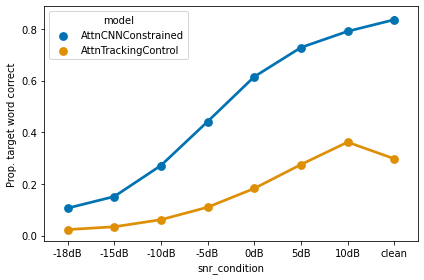

In [102]:
fig, axs = plt.subplots(1,2, sharey=True, figsize=(10,6))
# axs = axs.ravel()

g = sn.pointplot(
    data=bg_results, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', #hue_order=['unconstrained slope', 'constrained slope', "control"],
    ci=95, seed=1, #ax=axs[0],
    palette='colorblind', order=['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']
)


# g1 = sn.pointplot(
#     data=filtered_results, x='snr_condition',y='fg_confusion',
#     hue='model', hue_order=['unconstrained slope', 'constrained slope'],
#     ci=95, seed=1, ax=axs[1],
#     palette='colorblind', order=['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']
# )

g.set_ylabel("Prop. target word correct")
# axs[1].set_ylabel("Prop. error from target/background confusion")

plt.tight_layout()



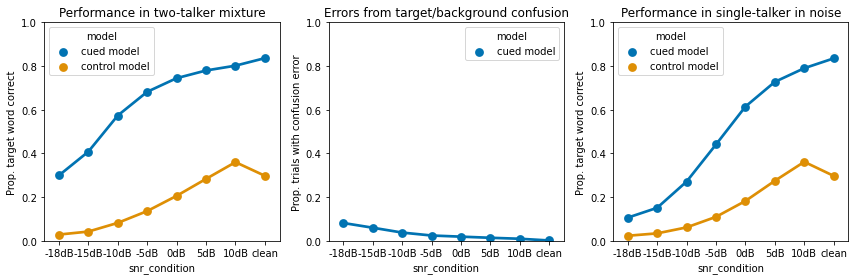

In [133]:
fig, axs = plt.subplots(1,3, figsize=(12,4))
axs = axs.ravel()

hue_order = ['cued model', "control model"]
snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

g = sn.pointplot(
    data=snr_results, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', hue_order=hue_order,
    ci=95, seed=1, ax=axs[0],
    palette='colorblind', order=snr_order
)


g1 = sn.pointplot(
    data=snr_results, x='snr_condition',y='fg_confusion',
    hue='model', hue_order=['cued model'],
    ci=95, seed=1, ax=axs[1],
    palette='colorblind', order=snr_order
)


g2 = sn.pointplot(
    data=bg_results, x='snr_condition', y='ACC/test_fg_acc',
    hue='model', hue_order=hue_order,
    ci=95, seed=1, ax=axs[2],
    palette='colorblind', order=snr_order
)


axs[0].set_title("Performance in two-talker mixture")
axs[1].set_title("Errors from target/background confusion")
axs[2].set_title("Performance in single-talker in noise")


axs[0].set_ylabel("Prop. target word correct")
axs[1].set_ylabel("Prop. trials with confusion error")
axs[2].set_ylabel("Prop. target word correct")

axs[0].set_ylim((0,1))
axs[1].set_ylim((0,1))
axs[2].set_ylim((0,1))



plt.tight_layout()

